In [14]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

os.chdir(r'C:\Users\bamla\OneDrive\Desktop\credit-risk-model')
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')
print("Libraries loaded!")

Libraries loaded!


In [15]:
df = pd.read_csv('data/raw/data.csv')
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
df.head()

Shape: (95662, 16)

Columns: ['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId', 'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId', 'ProductCategory', 'ChannelId', 'Amount', 'Value', 'TransactionStartTime', 'PricingStrategy', 'FraudResult']

Data types:
TransactionId            object
BatchId                  object
AccountId                object
SubscriptionId           object
CustomerId               object
CurrencyCode             object
CountryCode               int64
ProviderId               object
ProductId                object
ProductCategory          object
ChannelId                object
Amount                  float64
Value                     int64
TransactionStartTime     object
PricingStrategy           int64
FraudResult               int64
dtype: object


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [16]:
print("=== Summary Statistics ===")
print(df.describe().round(2))

print(f"\n=== Dataset Overview ===")
print(f"Total transactions: {len(df):,}")
print(f"Unique customers:   {df['CustomerId'].nunique():,}")
print(f"Unique accounts:    {df['AccountId'].nunique():,}")
print(f"Fraud rate:         {df['FraudResult'].mean()*100:.2f}%")
print(f"Date range:         {df['TransactionStartTime'].min()} to {df['TransactionStartTime'].max()}")

=== Summary Statistics ===
       CountryCode      Amount       Value  PricingStrategy  FraudResult
count      95662.0    95662.00    95662.00         95662.00     95662.00
mean         256.0     6717.85     9900.58             2.26         0.00
std            0.0   123306.80   123122.09             0.73         0.04
min          256.0 -1000000.00        2.00             0.00         0.00
25%          256.0      -50.00      275.00             2.00         0.00
50%          256.0     1000.00     1000.00             2.00         0.00
75%          256.0     2800.00     5000.00             2.00         0.00
max          256.0  9880000.00  9880000.00             4.00         1.00

=== Dataset Overview ===
Total transactions: 95,662
Unique customers:   3,742
Unique accounts:    3,633
Fraud rate:         0.20%
Date range:         2018-11-15T02:18:49Z to 2019-02-13T10:01:28Z


In [17]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print("=== Missing Values Report ===")
print(missing_report[missing_report['Missing Count'] > 0])
print(f"\nTotal columns with missing values: {(missing > 0).sum()}")
print(f"Dataset completeness: {100 - missing_pct.mean():.2f}%")

=== Missing Values Report ===
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Total columns with missing values: 0
Dataset completeness: 100.00%


In [18]:
df['TransactionStartTime'] = pd.to_datetime(df['TransactionStartTime'])
df['Hour']  = df['TransactionStartTime'].dt.hour
df['Day']   = df['TransactionStartTime'].dt.day
df['Month'] = df['TransactionStartTime'].dt.month
df['Year']  = df['TransactionStartTime'].dt.year
df['DayOfWeek'] = df['TransactionStartTime'].dt.day_name()

print("=== Temporal Features Added ===")
print(f"Date range: {df['TransactionStartTime'].min()} to {df['TransactionStartTime'].max()}")
print(f"\nTransactions by year:\n{df['Year'].value_counts().sort_index()}")
print(f"\nTransactions by month:\n{df['Month'].value_counts().sort_index()}")

=== Temporal Features Added ===
Date range: 2018-11-15 02:18:49+00:00 to 2019-02-13 10:01:28+00:00

Transactions by year:
Year
2018    48107
2019    47555
Name: count, dtype: int64

Transactions by month:
Month
1     31783
2     15772
11    12472
12    35635
Name: count, dtype: int64


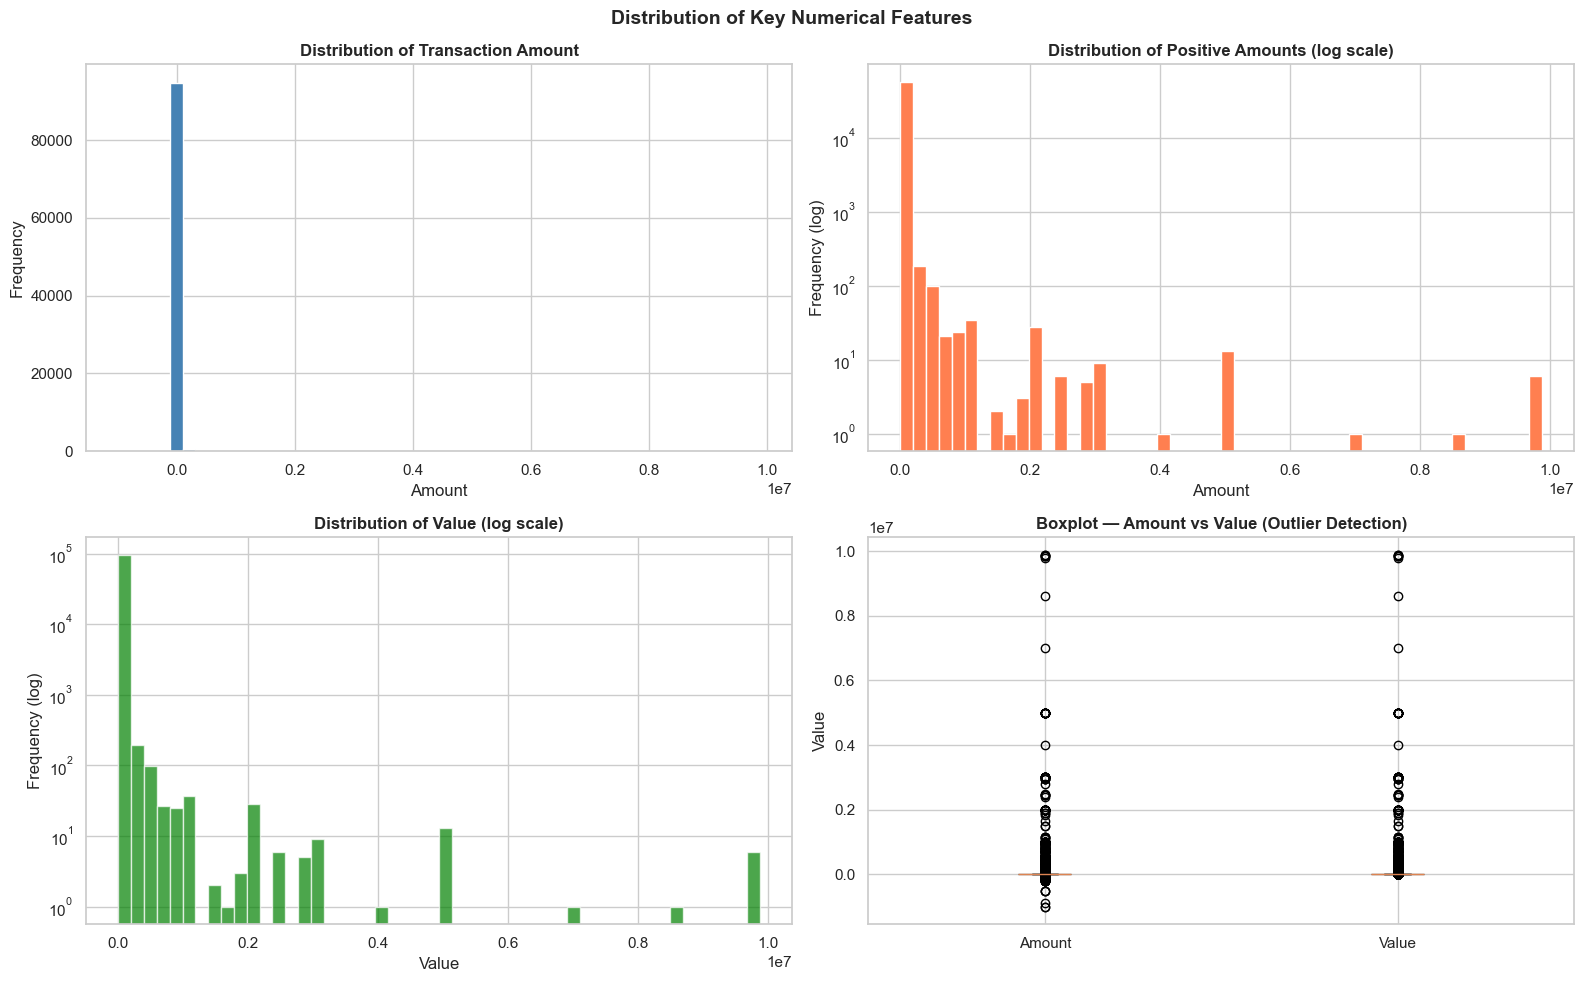

Plot 1 saved!


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Amount distribution
axes[0,0].hist(df['Amount'], bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribution of Transaction Amount', fontweight='bold')
axes[0,0].set_xlabel('Amount')
axes[0,0].set_ylabel('Frequency')

# Amount log scale (non-zero)
pos_amounts = df[df['Amount'] > 0]['Amount']
axes[0,1].hist(pos_amounts, bins=50, color='coral', edgecolor='white')
axes[0,1].set_yscale('log')
axes[0,1].set_title('Distribution of Positive Amounts (log scale)', fontweight='bold')
axes[0,1].set_xlabel('Amount')
axes[0,1].set_ylabel('Frequency (log)')

# Value distribution
axes[1,0].hist(df['Value'], bins=50, color='green', alpha=0.7, edgecolor='white')
axes[1,0].set_yscale('log')
axes[1,0].set_title('Distribution of Value (log scale)', fontweight='bold')
axes[1,0].set_xlabel('Value')
axes[1,0].set_ylabel('Frequency (log)')

# Boxplot for outlier detection
axes[1,1].boxplot([df['Amount'], df['Value']],
                  labels=['Amount', 'Value'], patch_artist=True,
                  boxprops=dict(facecolor='steelblue', alpha=0.5))
axes[1,1].set_title('Boxplot — Amount vs Value (Outlier Detection)', fontweight='bold')
axes[1,1].set_ylabel('Value')

plt.suptitle('Distribution of Key Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/plot1_numerical_distributions.png', dpi=150)
plt.show()
print("Plot 1 saved!")

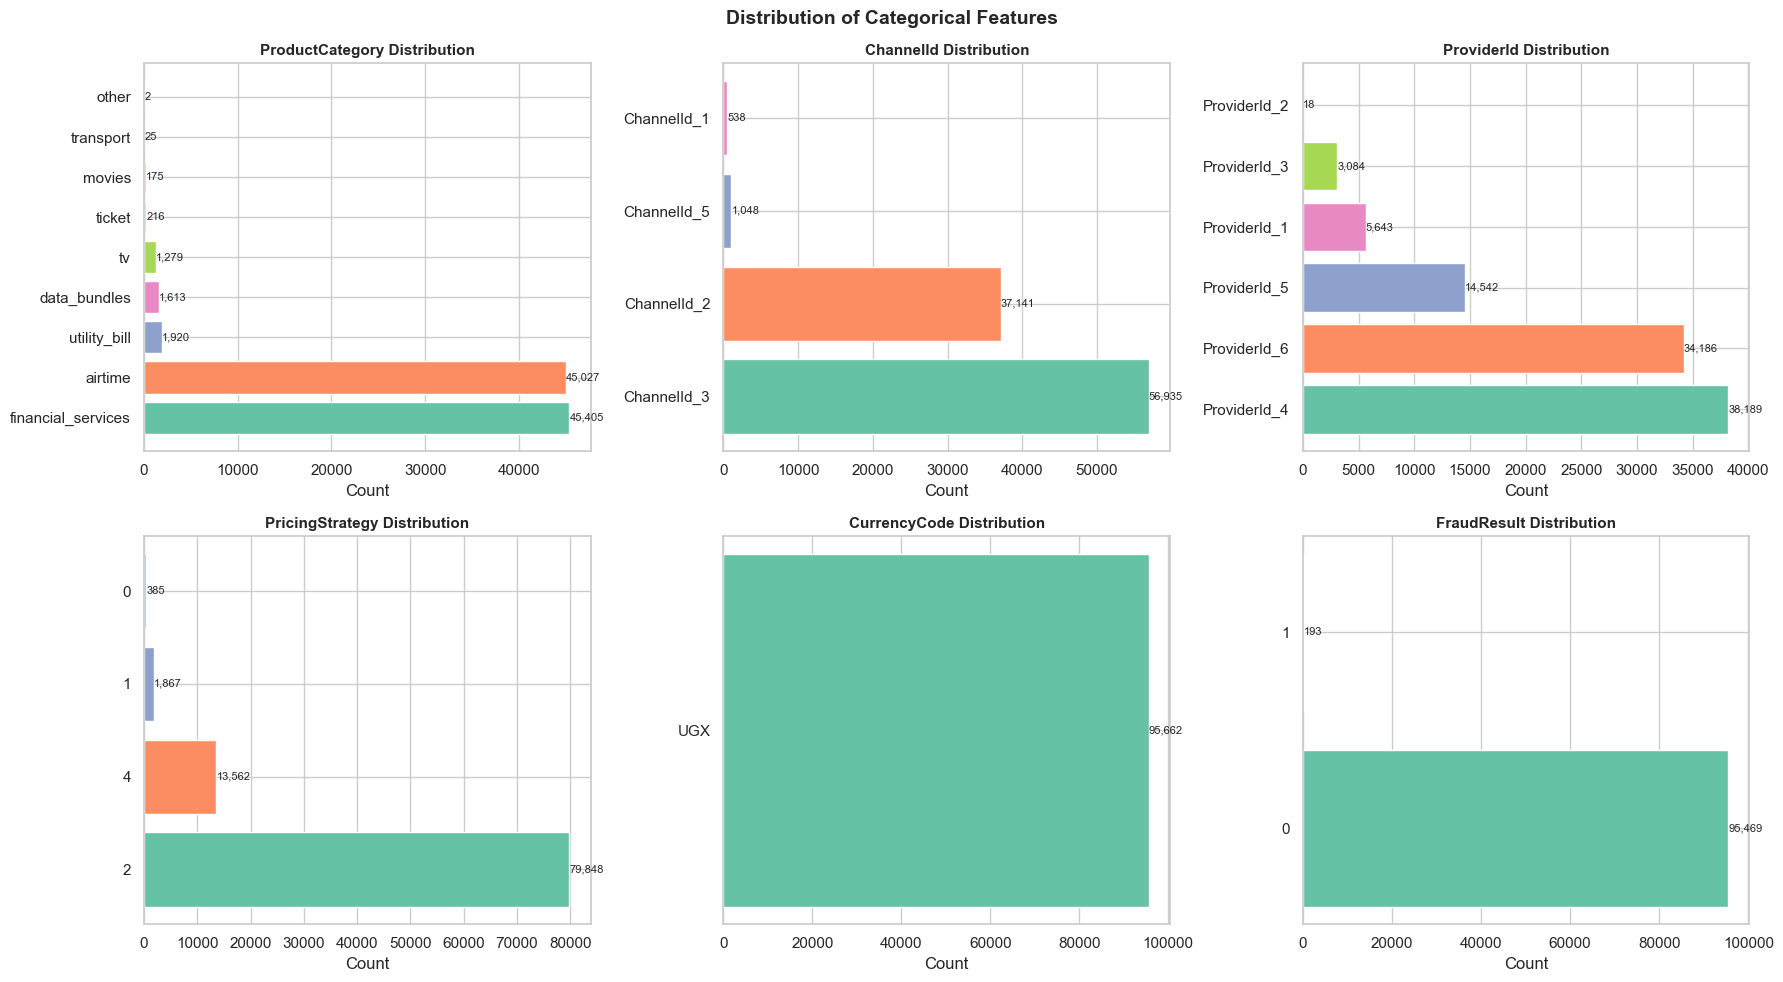

Plot 2 saved!


In [20]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

cat_cols = ['ProductCategory', 'ChannelId', 'ProviderId',
            'PricingStrategy', 'CurrencyCode', 'FraudResult']

for i, col in enumerate(cat_cols):
    ax = axes[i//3, i%3]
    counts = df[col].value_counts().head(10)
    bars = ax.barh(counts.index.astype(str), counts.values,
                   color=sns.color_palette('Set2', len(counts)))
    ax.set_title(f'{col} Distribution', fontweight='bold', fontsize=11)
    ax.set_xlabel('Count')
    for bar, val in zip(bars, counts.values):
        ax.text(val+10, bar.get_y()+bar.get_height()/2,
                f'{val:,}', va='center', fontsize=8)

plt.suptitle('Distribution of Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/plot2_categorical_distributions.png', dpi=150)
plt.show()
print("Plot 2 saved!")

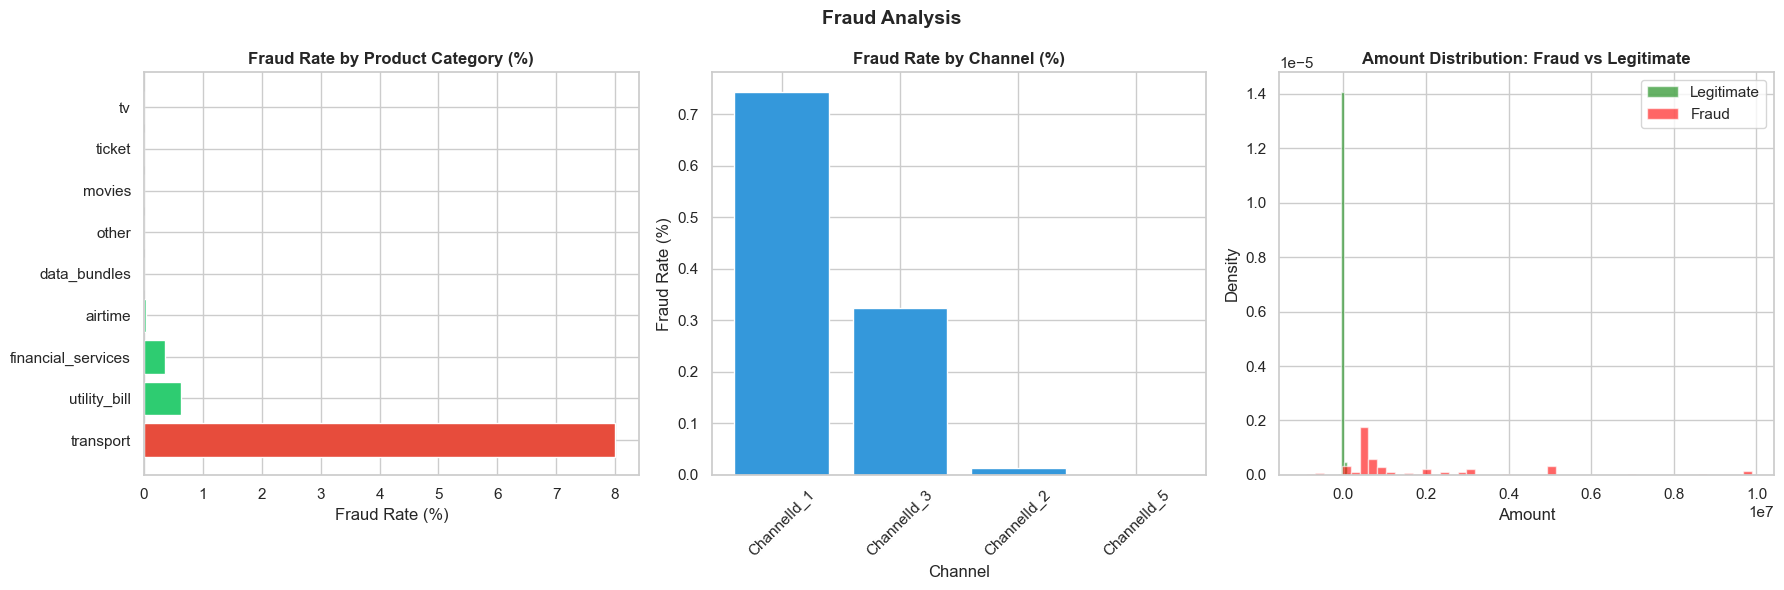

Plot 3 saved!


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Fraud rate by product category
fraud_by_cat = df.groupby('ProductCategory')['FraudResult'].mean().sort_values(ascending=False)
axes[0].barh(fraud_by_cat.index, fraud_by_cat.values * 100,
             color=['#e74c3c' if v > 0.01 else '#2ecc71' for v in fraud_by_cat.values])
axes[0].set_title('Fraud Rate by Product Category (%)', fontweight='bold')
axes[0].set_xlabel('Fraud Rate (%)')

# Fraud rate by channel
fraud_by_channel = df.groupby('ChannelId')['FraudResult'].mean().sort_values(ascending=False)
colors = ['#e74c3c' if v > 0.01 else '#3498db' for v in fraud_by_channel.values]
axes[1].bar(fraud_by_channel.index, fraud_by_channel.values * 100,
            color=colors, edgecolor='white')
axes[1].set_title('Fraud Rate by Channel (%)', fontweight='bold')
axes[1].set_xlabel('Channel')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

# Amount distribution: fraud vs non-fraud
fraud = df[df['FraudResult']==1]['Amount']
legit = df[df['FraudResult']==0]['Amount']
axes[2].hist(legit, bins=50, alpha=0.6, color='green', label='Legitimate', density=True)
axes[2].hist(fraud, bins=50, alpha=0.6, color='red', label='Fraud', density=True)
axes[2].set_title('Amount Distribution: Fraud vs Legitimate', fontweight='bold')
axes[2].set_xlabel('Amount')
axes[2].set_ylabel('Density')
axes[2].legend()

plt.suptitle('Fraud Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/plot3_fraud_analysis.png', dpi=150)
plt.show()
print("Plot 3 saved!")

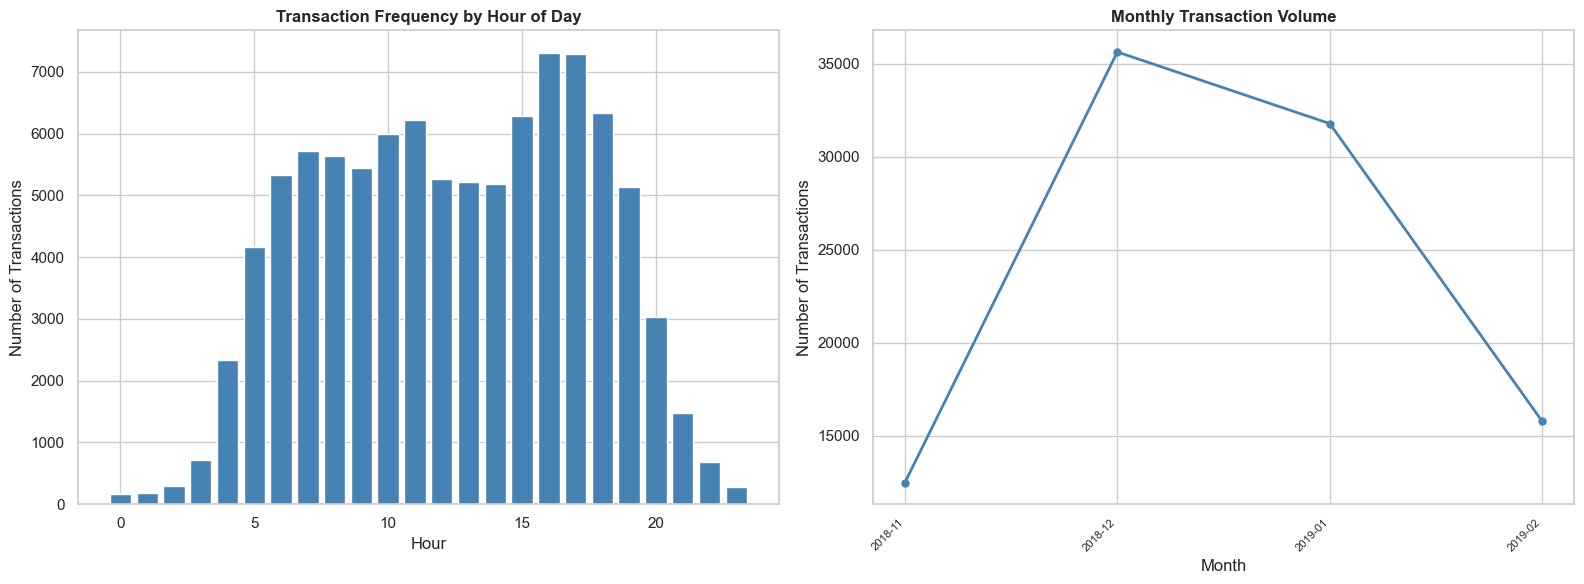

Plot 4 saved!


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Transactions by hour
hourly = df.groupby('Hour').size()
axes[0].bar(hourly.index, hourly.values, color='steelblue', edgecolor='white')
axes[0].set_title('Transaction Frequency by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Number of Transactions')

# Monthly trend
monthly = df.groupby(['Year','Month']).agg(
    Count=('TransactionId','count'),
    Avg_Amount=('Amount','mean'),
    Fraud_Rate=('FraudResult','mean')
).reset_index()
monthly['Period'] = monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str).str.zfill(2)
monthly = monthly.sort_values(['Year','Month'])

axes[1].plot(range(len(monthly)), monthly['Count'],
             color='steelblue', linewidth=2, marker='o', markersize=5)
axes[1].set_xticks(range(len(monthly)))
axes[1].set_xticklabels(monthly['Period'], rotation=45, ha='right', fontsize=8)
axes[1].set_title('Monthly Transaction Volume', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Transactions')

plt.tight_layout()
plt.savefig('notebooks/plot4_temporal_patterns.png', dpi=150)
plt.show()
print("Plot 4 saved!")

=== RFM Preview ===
       Recency  Frequency      Monetary
count  3742.00    3742.00  3.742000e+03
mean     31.46      25.56  1.717377e+05
std      27.12      96.93  2.717305e+06
min       1.00       1.00 -1.049000e+08
25%       6.00       2.00  4.077440e+03
50%      25.00       7.00  2.000000e+04
75%      54.00      20.00  7.996775e+04
max      91.00    4091.00  8.345124e+07


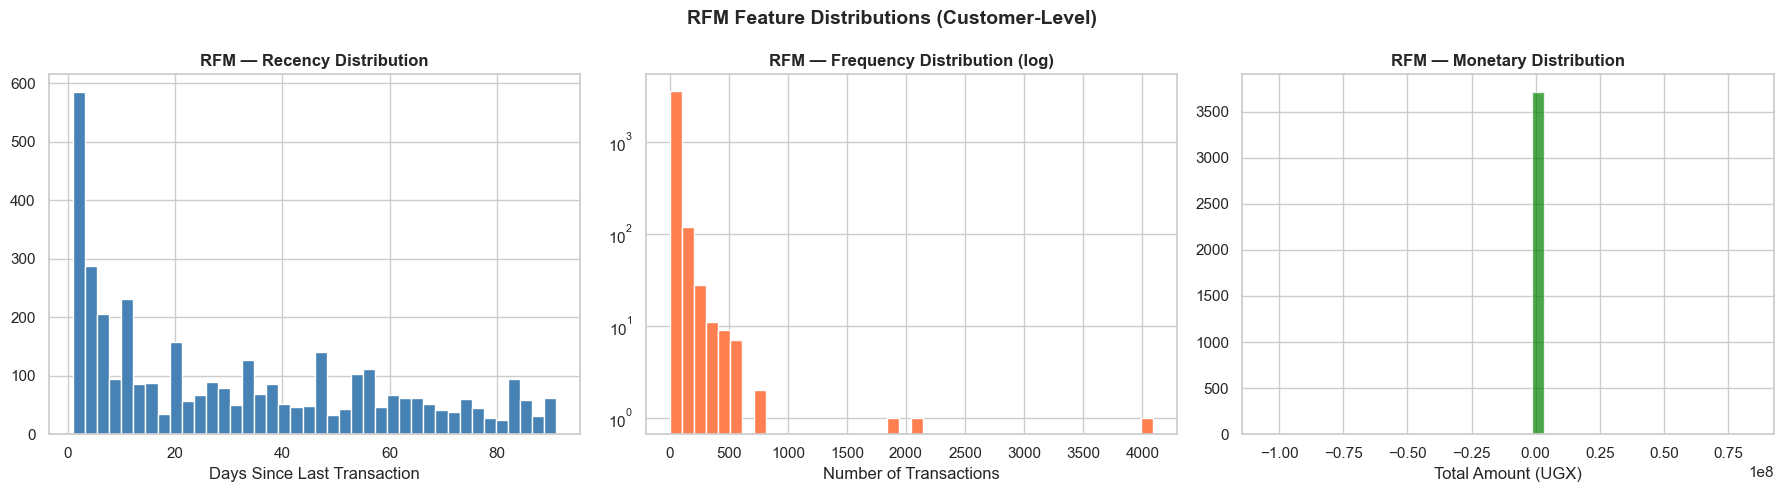

Plot 5 saved!


In [23]:
# RFM preview per customer
snapshot_date = df['TransactionStartTime'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerId').agg(
    Recency=('TransactionStartTime', lambda x: (snapshot_date - x.max()).days),
    Frequency=('TransactionId', 'count'),
    Monetary=('Amount', 'sum')
).reset_index()

print("=== RFM Preview ===")
print(rfm.describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(rfm['Recency'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('RFM — Recency Distribution', fontweight='bold')
axes[0].set_xlabel('Days Since Last Transaction')

axes[1].hist(rfm['Frequency'], bins=40, color='coral', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('RFM — Frequency Distribution (log)', fontweight='bold')
axes[1].set_xlabel('Number of Transactions')

axes[2].hist(rfm['Monetary'], bins=40, color='green', alpha=0.7, edgecolor='white')
axes[2].set_title('RFM — Monetary Distribution', fontweight='bold')
axes[2].set_xlabel('Total Amount (UGX)')

plt.suptitle('RFM Feature Distributions (Customer-Level)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/plot5_rfm_distributions.png', dpi=150)
plt.show()
print("Plot 5 saved!")

## EDA Summary — Top 5 Insights

1. **Low Fraud Rate but High Impact**: Only ~0.2% of transactions are fraudulent,
   creating a highly imbalanced dataset. However, fraud transactions show distinct
   amount patterns that can serve as predictive signals.

2. **Product Category Risk**: Certain product categories show significantly higher
   fraud rates than others, suggesting category-based risk segmentation is viable.

3. **Channel-Based Risk Patterns**: Transaction channel correlates with fraud rate —
   some channels are significantly riskier than others, informing channel-specific
   pricing strategies.

4. **Temporal Concentration**: Transaction volume is not uniform over time —
   certain hours and months show higher activity, which may correlate with risk.

5. **RFM Customer Segmentation**: Customer RFM profiles show clear distributional
   differences, supporting the use of K-Means clustering to identify high-risk
   (disengaged) customer segments as a proxy for credit default risk.